**REQUIREMENTS**

This is an python libary that allows easy API calls to the Meteostat. Meteostat is an open source project that stores historic weather data. This library will be used for obtaining weather data as explained in the proposal.

---

In [ ]:
%pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 21.4 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pa

**EDA Phase**

These datasets contain different .csv files so the first goal is to understand what each of the .csv files contain. To understand it, some of the relevant .csv files are selected and first 5 - 20 rows are selected.

---



In [ ]:
import pandas as pd
import numpy as np
import meteostat as ms
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from datetime import datetime

In [ ]:
result_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/results.csv')
races_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/races.csv')
pitstop_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/pit_stops.csv')
circuit_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/circuits.csv')
lap_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/lap_times.csv')


In [ ]:
result_data.head(20)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.18,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.1,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


**Non-Essential Columns in Result Dataset:**


1.   positionText and position: The finish order of the racers in an race can be found in positionOrder.
2.   fastestLapSpeed: For some drivers it is not avaliable and it will not be used in this project.
3.   number: It is the number of the driver which is not neccessary since drivers are identified through driverId.
4.   time and milliseconds: It contains the finish times after the winner however it is both not neccessary and contain missing values.
5.   points: The point system changes recently in F1 therefore some races contain old format and some contain the new format.

In this dataset the rank column gives the rank of the driver according to their fastest lap.

---



In [ ]:
races_data.head(5)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1182,2026,14,81,Spanish Grand Prix,2026-09-13,13:00:00,https://en.wikipedia.org/wiki/2026_Spanish_Gra...,2026-09-11,11:30:00,2026-09-11,15:00:00,2026-09-12,10:30:00,2026-09-12,14:00:00,\N,\N
1,1188,2026,20,80,Las Vegas Grand Prix,2026-11-22,4:00:00,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,2026-11-20,0:30:00,2026-11-20,4:00:00,2026-11-21,0:30:00,2026-11-21,4:00:00,\N,\N
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,https://en.wikipedia.org/wiki/2025_Las_Vegas_G...,2025-11-21,0:30:00,2025-11-21,4:00:00,2025-11-22,0:30:00,2025-11-22,4:00:00,\N,\N
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,2:30:00,2024-11-21,6:00:00,2024-11-22,2:30:00,2024-11-22,6:00:00,\N,\N
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,https://en.wikipedia.org/wiki/2023_Las_Vegas_G...,2023-11-16,4:30:00,2023-11-16,8:00:00,2023-11-17,4:30:00,2023-11-17,8:00:00,\N,\N


**Non-Essential Columns in Race Dataset**



1.   FP1, FP2 etc. refers to different practice sessions time which is not neccessary since this project will not use those times.
2.   url

---



In [ ]:
pitstop_data.head(5)

,raceId,driverId,stop,lap,time,duration,milliseconds
0,258,100,1,1,14:01:34,49.111,49111
1,258,79,1,17,14:20:46,28.482,28482
2,258,57,1,18,14:22:35,43.745,43745
3,258,71,1,18,14:23:00,21.992,21992
4,258,105,1,19,14:24:39,27.693,27693


**Non-Essential Columns in Pitstop Data**



1.   time: Since the pit stop lap is known, it is easier to work with therefore this column is not neccessary.

---



In [ ]:
circuit_data.head(5)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Sepang,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


**Non-Essential Columns in Circuit Data**



1.   url

---

In [ ]:
lap_data.head(10)

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342
5,841,20,6,1,1:32.605,92605
6,841,20,7,1,1:32.502,92502
7,841,20,8,1,1:32.537,92537
8,841,20,9,1,1:33.240,93240
9,841,20,10,1,1:32.572,92572


**Lap Data**

This contains information about drivers each race and their lap times in each lap. All columns contain valuable information.

---

In [ ]:
result_data.drop(columns=['number', 'fastestLapSpeed', 'position', 'positionText', 'time', 'milliseconds'], inplace=True)
races_data.drop(columns=['url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time'], inplace=True)
pitstop_data.drop(columns=['time'], inplace=True)
circuit_data.drop(columns=['url'], inplace=True)

**Important Changes**

Since F1 started in 1950 there have been number of regulations and chages to the cars. Therefore, to create an logical model only races after 2010 will be considered.

Also, the race and result data will be merged since they contain valuable information about the each race. Therefore the raceId, driverId and circuitId columns can be used simultaneously for different merges of datasets.

---

In [ ]:
race_result_merge = pd.merge(races_data, result_data, on='raceId', how='inner')
race_result_merge.head(10)

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,grid,positionOrder,points,laps,fastestLap,rank,fastestLapTime,statusId
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,2,1,25.0,50,50,1,1:33.365,1
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,4,2,18.0,50,50,9,1:34.592,1
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,17,3,15.0,50,48,2,1:33.998,1
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,9,4,12.0,50,43,3,1:34.304,1
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,3,5,10.0,50,42,4,1:34.496,1
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27189,865,215,8,6,8.0,50,50,10,1:34.620,1
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27190,807,15,11,7,6.0,50,49,8,1:34.592,1
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27191,1,6,19,8,4.0,50,49,6,1:34.553,1
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27192,839,210,13,9,2.0,50,48,7,1:34.557,1
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27193,860,210,14,10,1.0,50,50,5,1:34.519,1


In [ ]:
print(f"Length Before: {len(race_result_merge)}")
race_result_merge = race_result_merge[(race_result_merge['year'] >= 2010) & (race_result_merge['year'] < 2026)]
print(f"Length After: {len(race_result_merge)}")


Length Before: 27284
Length After: 6895


Now this dataset can be used as the main dataset to merge with other datasets. Thus making it easy to get information about each driver for each race.

---

In [ ]:
pitstop_race = pd.merge(race_result_merge, pitstop_data, on=['raceId', 'driverId'], how='inner')
pitstop_race.head(10)

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,...,points,laps,fastestLap,rank,fastestLapTime,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,...,25.0,50,50,1,1:33.365,1,1,25,21.708,21708
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,...,18.0,50,50,9,1:34.592,1,1,17,20.929,20929
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,...,15.0,50,48,2,1:33.998,1,1,2,21.968,21968
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,...,12.0,50,43,3,1:34.304,1,1,24,21.351,21351
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,...,10.0,50,42,4,1:34.496,1,1,22,21.164,21164
5,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27189,865,215,...,8.0,50,50,10,1:34.620,1,1,20,21.324,21324
6,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27190,807,15,...,6.0,50,49,8,1:34.592,1,1,30,22.333,22333
7,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27191,1,6,...,4.0,50,49,6,1:34.553,1,1,29,21.638,21638
8,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27192,839,210,...,2.0,50,48,7,1:34.557,1,1,27,22.389,22389
9,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27193,860,210,...,1.0,50,50,5,1:34.519,1,1,17,21.491,21491


In [ ]:
for col in pitstop_race.columns:
  print(col)

raceId
year
round
circuitId
name
date
time
resultId
driverId
constructorId
grid
positionOrder
points
laps
fastestLap
rank
fastestLapTime
statusId
stop
lap
duration
milliseconds


Check for empty values in the pitstop times.

In [ ]:
print((pitstop_race['milliseconds'] == r'\N').any())

False


In [ ]:
print((pitstop_race['milliseconds'] == '0').any())

False


**Average Pit Stop Times by Season**

This graph gives the avg pitstop times and their change throughout the years. From the graph it can be seen that generally before 2020 most of the pit stop times are lower than 5000 milliseconds. However, after 2020 the pitstop times have at least doubled and in year 2021 has significantly higher avg compared to the other years.

---

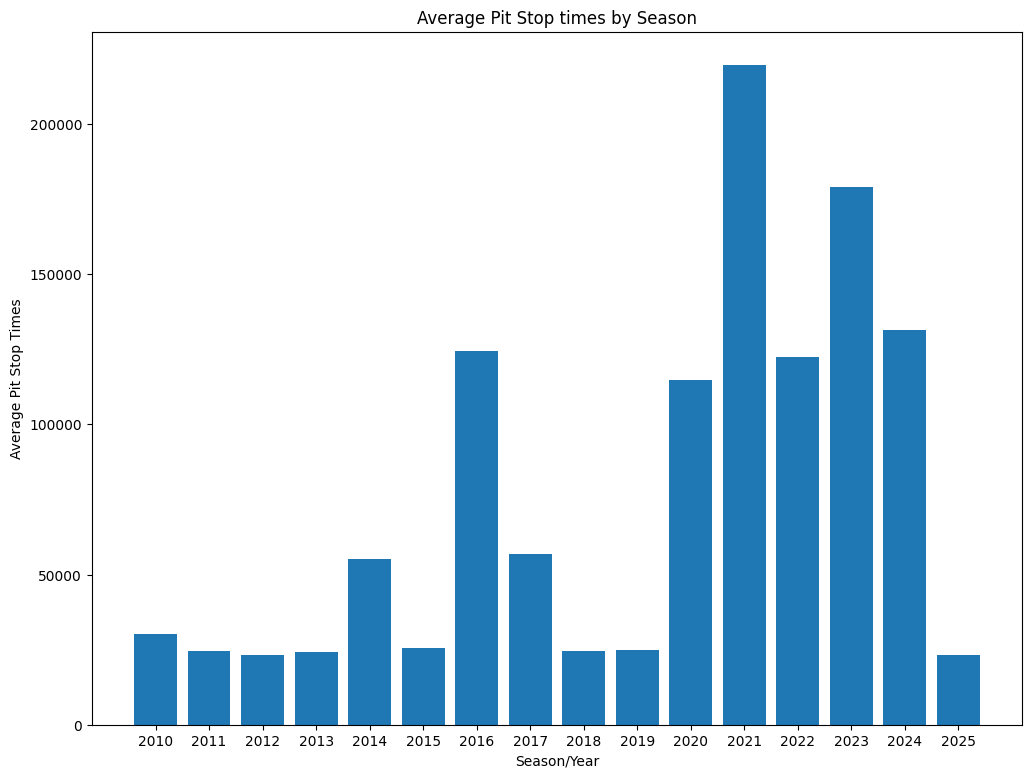

In [ ]:
pitstop_race['milliseconds'] = pd.to_timedelta(pitstop_race['milliseconds'])
avg_pit_stop_times = (pitstop_race.dropna(subset=['year', 'milliseconds']).groupby('year')['milliseconds'].mean().sort_index().reset_index())
fig, ax = plt.subplots(figsize=(12, 9))
ax.bar(avg_pit_stop_times['year'], avg_pit_stop_times['milliseconds'])
ax.set_xticks(avg_pit_stop_times['year'])
ax.set_xlabel('Season/Year')
ax.set_ylabel('Average Pit Stop Times')
ax.set_title('Average Pit Stop times by Season')
plt.show()

**First Pit Stop**

In F1 the different tracks can have different number of ideal pit stop counts. However due to the regulations every driver MUST pit at least once in each race. Therefore the first pit stop laps can be analyzed with different features for correlation.

---

In [ ]:
first_pit_stop_subset = pitstop_race[pitstop_race['stop'] == 1]
first_pit_stop_subset['lap'] = first_pit_stop_subset['lap'].astype(int)
avg_pit_stop_each_race = (first_pit_stop_subset.dropna(subset=['name', 'lap']).groupby('name')['lap'].mean().sort_index().reset_index())
avg_pit_stop_each_race

,name,lap
0,70th Anniversary Grand Prix,15.200000
1,Abu Dhabi Grand Prix,17.189873
2,Australian Grand Prix,13.636364
3,Austrian Grand Prix,20.102222
4,Azerbaijan Grand Prix,15.797297
5,Bahrain Grand Prix,11.561873
6,Belgian Grand Prix,11.087413
7,Brazilian Grand Prix,16.292079
8,British Grand Prix,14.599349
9,Canadian Grand Prix,20.572464


**First Pit Stop Graph**

From this graph it can be seen that the first pit stop lap can change significantly for different circuits maximum being lap 30 and min being lap 12. However for most of the circuits racers pit in lap 15 - 20.

---

Text(0, 0.5, 'First Pit Stop Lap')

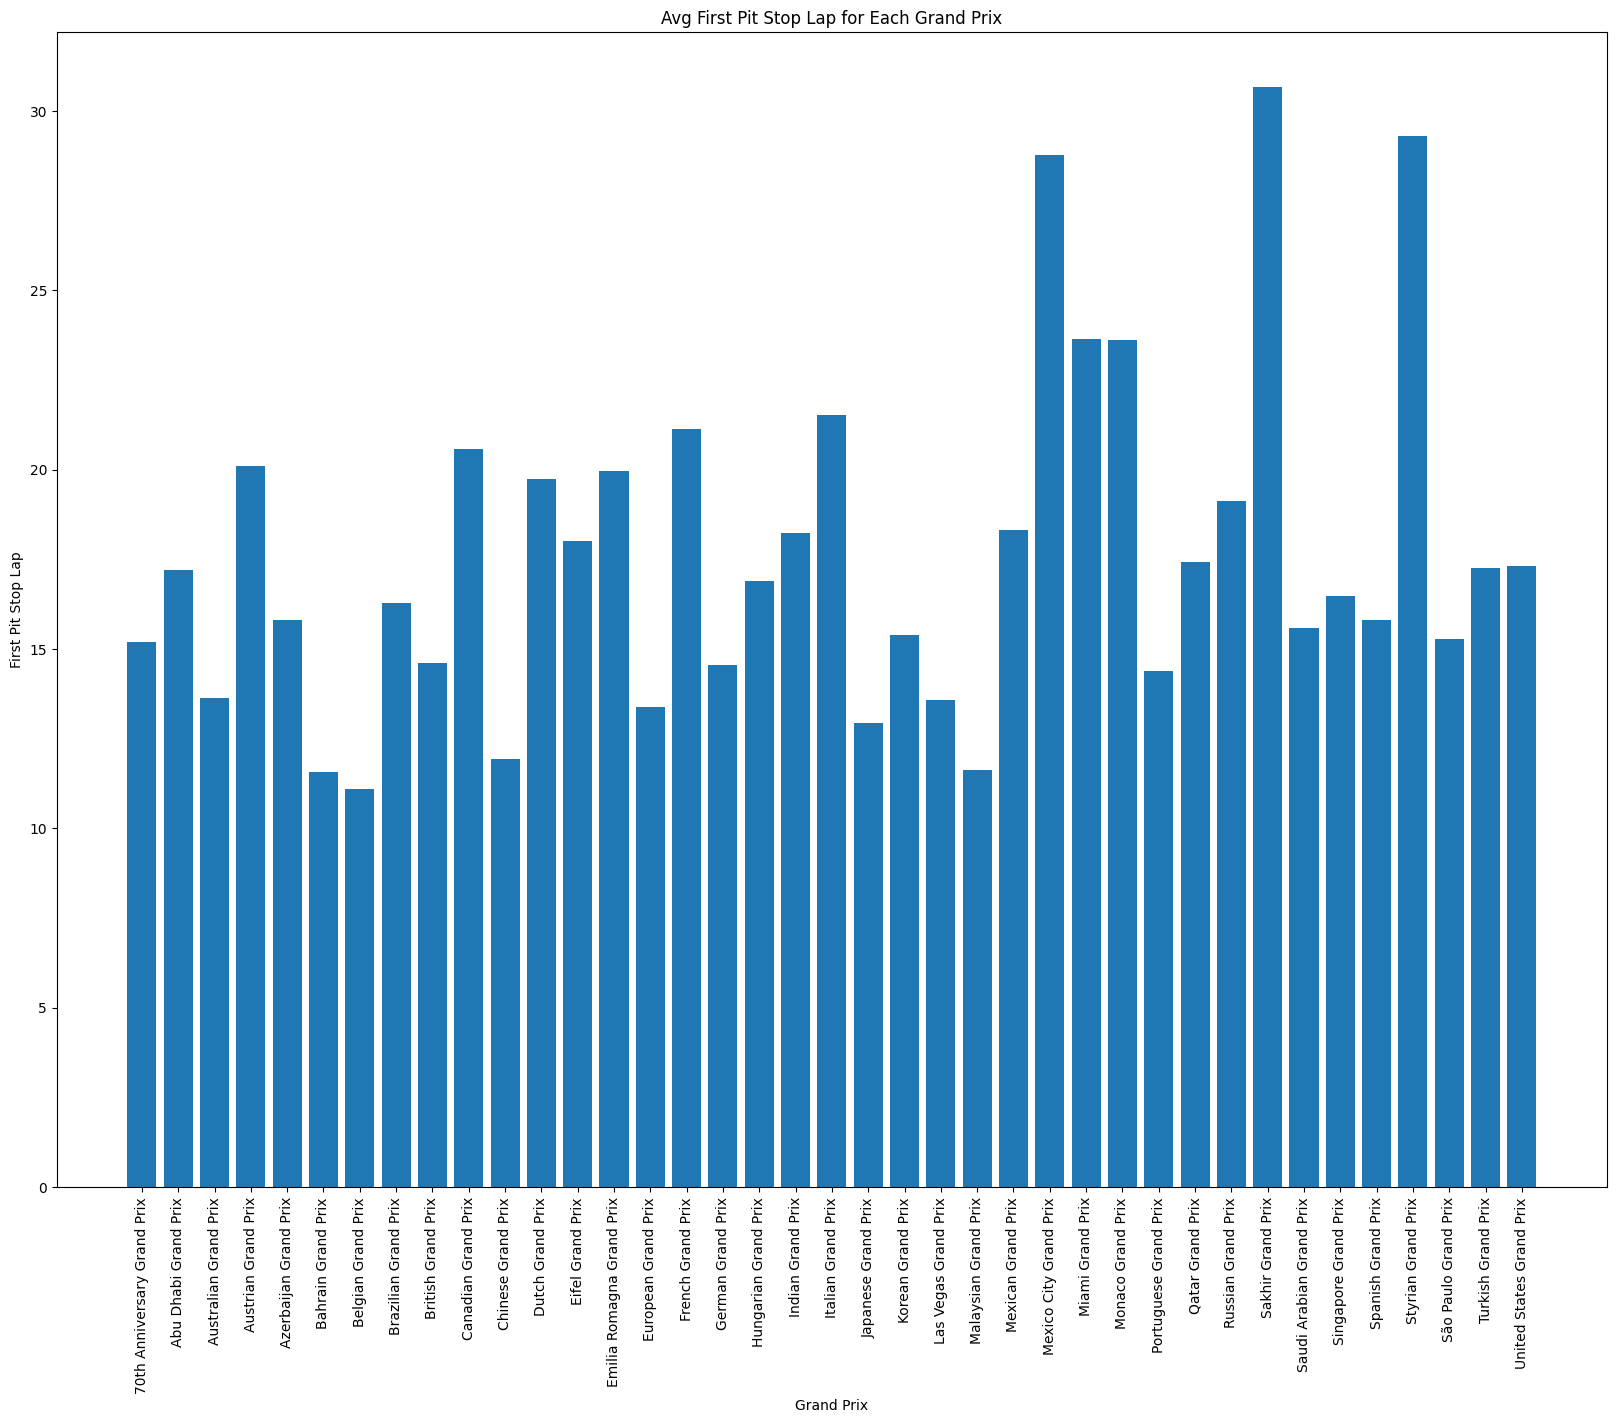

In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))
ax.bar(avg_pit_stop_each_race['name'], avg_pit_stop_each_race['lap'])
ax.tick_params(axis='x', rotation=90)
ax.set_title('Avg First Pit Stop Lap for Each Grand Prix')
ax.set_xlabel('Grand Prix')
ax.set_ylabel('First Pit Stop Lap')

**First Pit Stop for Iconic Races**

British, Japanese and Monaco are held in the same circuit for a great number of years. Therefore first pit stop laps of these circuits can be used for finding an pattern.

---

In [ ]:
monaco = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "Monaco Grand Prix"]
monaco = (monaco.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
monaco

,year,lap
0,2010,19.578947
1,2011,24.434783
2,2012,28.714286
3,2013,24.000000
4,2014,22.842105
5,2015,25.736842
6,2016,15.650000
7,2017,32.894737
8,2018,20.200000
9,2019,24.050000


In [ ]:
jp = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "Japanese Grand Prix"]
jp = (jp.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
jp

,year,lap
0,2010,20.500000
1,2011,11.708333
2,2012,13.863636
3,2013,9.950000
4,2014,2.000000
5,2015,11.050000
6,2016,15.454545
7,2017,21.470588
8,2018,20.500000
9,2019,18.157895


In [ ]:
br = first_pit_stop_subset.loc[first_pit_stop_subset['name'] == "British Grand Prix"]
br = (br.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index().reset_index())
br

,year,lap
0,2010,16.782609
1,2011,11.409091
2,2012,13.739130
3,2013,11.500000
4,2014,23.529412
5,2015,18.866667
6,2016,5.818182
7,2017,22.277778
8,2018,20.052632
9,2019,14.105263


**Graph Analysis**

From the graph it can be seen that British GP and Japanese GP sometimes follow a similar trend however Monaco does not follow that trend. This may be due to British and Japanese GP being an track circuit and Monaco being an street circuit.

---

Text(0.5, 1.0, 'Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP')

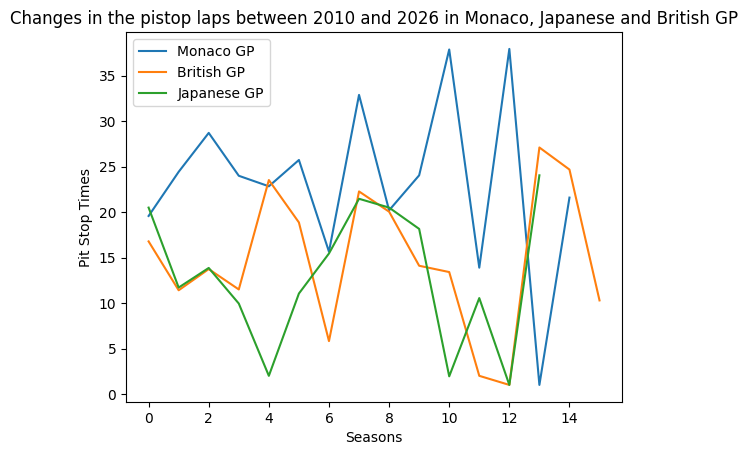

In [ ]:
plt.plot(monaco['lap'], label="Monaco GP")
plt.plot(br['lap'], label = "British GP")
plt.plot(jp['lap'], label = "Japanese GP")
plt.xlabel("Seasons")
plt.legend(loc="upper left")
plt.ylabel("Pit Stop Times")
plt.title("Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP")

In [ ]:
pitstop_race_final = pitstop_race[pitstop_race['stop'] == 1]
pitstop_race_final

,raceId,year,round,circuitId,name,date,time,resultId,driverId,constructorId,...,points,laps,fastestLap,rank,fastestLapTime,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27184,830,9,...,25.0,50,50,1,1:33.365,1,1,25,21.708,0 days 00:00:00.000021708
1,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27185,847,131,...,18.0,50,50,9,1:34.592,1,1,17,20.929,0 days 00:00:00.000020929
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27186,863,131,...,15.0,50,48,2,1:33.998,1,1,2,21.968,0 days 00:00:00.000021968
3,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27187,844,6,...,12.0,50,43,3,1:34.304,1,1,24,21.351,0 days 00:00:00.000021351
4,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,27188,832,3,...,10.0,50,42,4,1:34.496,1,1,22,21.164,0 days 00:00:00.000021164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12711,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20360,812,164,...,0.0,53,48,16,1:35.045,15,1,8,27.526,0 days 00:00:00.000027526
12713,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20361,10,166,...,0.0,41,37,15,1:34.230,22,1,9,28.501,0 days 00:00:00.000028501
12714,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20362,810,166,...,0.0,26,17,17,1:36.607,9,1,10,27.693,0 days 00:00:00.000027693
12716,338,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,20363,20,9,...,0.0,25,22,13,1:31.556,36,1,9,24.527,0 days 00:00:00.000024527


**Data Creation for Hypothesi Test 1**

---

In [ ]:
pitstop_race_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test1.csv')


**Track Table**

This table is created to have information about tracks in an single table.

---

In [ ]:
race_location = pd.merge(races_data, circuit_data, on=['circuitId'], how='inner')
race_location = race_location[(race_location['year'] >= 2010) & (race_location['year'] < 2026)]
race_location.drop(columns=['name_y'], inplace=True)
race_location.head(5)


,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642
6,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0
7,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0


**Temprature Data**

In this part the temprature data for each grand prix is collected by using the previous table. In the previous table the date and coordinates of the tracks are available therefore by using them it sends requests to Meteostat for weather information. (The print of numbers is only used for checking if it works correctly)

---

In [ ]:
race_location['temp'] = np.nan
i = 0

for index, row in race_location.iterrows():
  print(i)
  date = row['date'].split('-')
  new_month = date[1]
  if(date[1][0] == '0'):
    new_month = date[1][1]
  date[1] = new_month

  time = row['time'].split(':')
  start = datetime(int(date[0]), int(date[1]), int(date[2]))
  end = start
  POINT = ms.Point(float(row['lat']), float(row['lng']))
  stations = ms.stations.nearby(POINT, radius=200000, limit=4)
  ts = ms.daily(station=stations, start=start, end=end)
  df = ts.fetch()
  if(df is not None):
    if('temp' in df.columns):
      race_location.loc[index, 'temp'] = df['temp'].iloc[0]
    elif('tmin' in df.columns and 'tmax' in df.columns):
      race_location.loc[index, 'temp'] = (df['tmax'].iloc[0] + df['tmin'].iloc[0])/2
  i += 1
race_location.head(10)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp
2,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2
3,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6
4,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2
6,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9
7,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4
8,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1
9,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7
11,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6
12,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8
13,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4


**Analysis of Results**

This part is used for checking how many races have the weather so that only those could be used in analysis. From the graph it can be seen that it found weather data for the huge majority of the races.

---

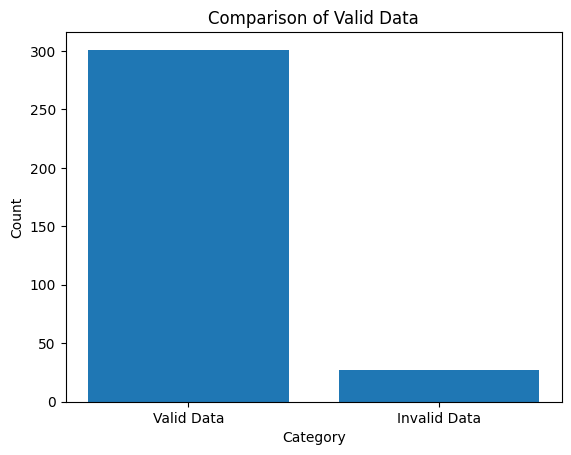

In [ ]:
invalid_data = race_location['temp'].isnull().sum()
valid_data = len(race_location) - invalid_data


legend = ['Valid Data', 'Invalid Data']
vals = [valid_data, invalid_data]

plt.bar(legend, vals)
plt.title("Comparison of Valid Data")
plt.xlabel("Category")
plt.ylabel('Count')
plt.show()

**Analysis of Results 2**

This graph is used for whether the missing data comes from the same races or for a specific season. The graph shows that the majority comes from British GP and Russian GP.

---

Text(0, 0.5, 'Counts')

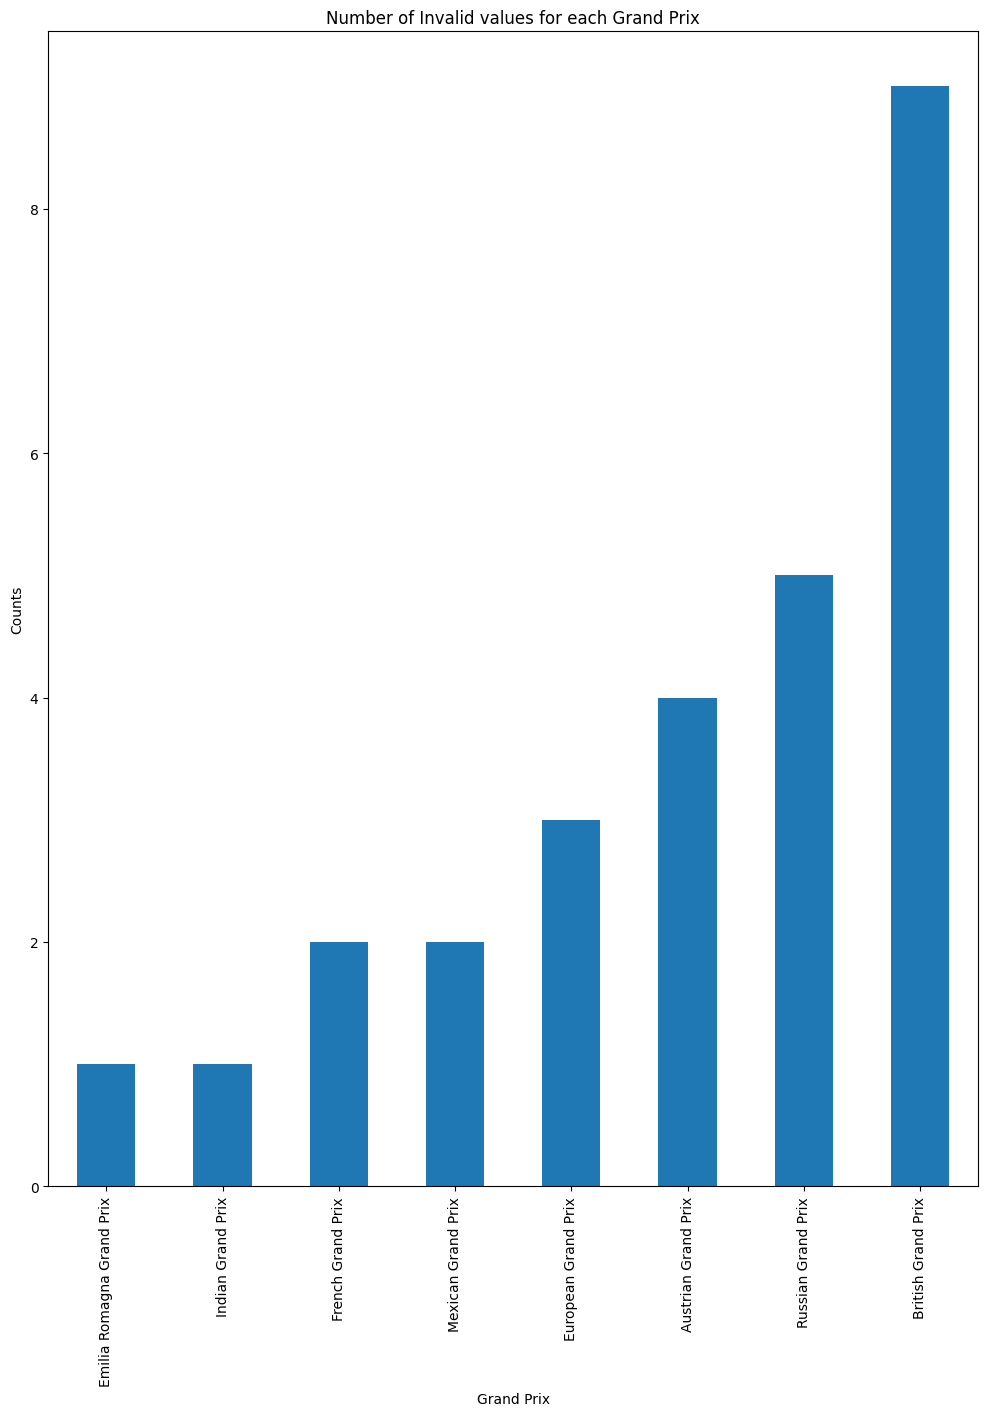

In [ ]:
invalid_races = race_location[['name_x', 'temp']]
invalid_races = invalid_races[invalid_races['temp'].isnull()]
invalid_races = invalid_races.groupby('name_x').size().sort_values()
fig, ax = plt.subplots(figsize=(12, 15))
invalid_races.plot(kind='bar', ax=ax)
ax.set_title('Number of Invalid values for each Grand Prix')
ax.set_xlabel('Grand Prix')
ax.set_ylabel('Counts')


In [ ]:
print(f"Count of Total Races after 2010: {len(race_location)}")
race_location_temp = race_location[race_location['temp'].notna()]
print(f"Races with valid temprature data after 2010: {len(race_location_temp)} ")

Count of Total Races after 2010: 328
Races with valid temprature data after 2010: 301 


**Create the Table for the Hypothesis Test 2**

---

In [ ]:
stop_count = pitstop_data.groupby(['raceId'])['stop'].mean().reset_index()
stop_count

,raceId,stop
0,1,1.666667
1,2,2.000000
2,3,1.483871
3,4,1.571429
4,5,1.718750
...,...,...
595,1167,1.609756
596,1168,1.259259
597,1169,1.531250
598,1170,1.105263


In [ ]:
hyp2_final = pd.merge(stop_count, race_location_temp, on=['raceId'], how='inner')
hyp2_final['stop_rank'] = hyp2_final['stop'].rank()
hyp2_final['temp_rank'] = hyp2_final['temp'].rank()
hyp2_final

,raceId,stop,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop_rank,temp_rank
0,337,1.095238,2010,1,3,Bahrain Grand Prix,2010-03-14,12:00:00,bahrain,Sakhir,Bahrain,26.03250,50.51060,7,26.1,18.0,258.5
1,338,1.428571,2010,2,1,Australian Grand Prix,2010-03-28,6:00:00,albert_park,Melbourne,Australia,-37.84970,144.96800,10,21.8,123.5,189.5
2,339,1.150000,2010,3,2,Malaysian Grand Prix,2010-04-04,8:00:00,sepang,Sepang,Malaysia,2.76083,101.73800,18,29.9,39.0,297.0
3,340,2.567164,2010,4,17,Chinese Grand Prix,2010-04-18,6:00:00,shanghai,Shanghai,China,31.33890,121.22000,5,17.3,293.0,98.5
4,341,1.250000,2010,5,4,Spanish Grand Prix,2010-05-09,12:00:00,catalunya,Montmeló,Spain,41.57000,2.26111,109,15.1,72.5,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1164,1.333333,2025,20,32,Mexico City Grand Prix,2025-10-26,20:00:00,rodriguez,Mexico City,Mexico,19.40420,-99.09070,2227,19.0,98.0,139.0
296,1165,1.594595,2025,21,18,São Paulo Grand Prix,2025-11-09,17:00:00,interlagos,São Paulo,Brazil,-23.70360,-46.69970,785,16.4,175.0,73.5
297,1166,1.217391,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,14.2,55.5,32.0
298,1167,1.609756,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.49000,51.45420,12,21.6,182.5,185.0


In [ ]:
hyp2_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test2.csv')


**Data Creation for Hypothesis Test 3**

---

In [ ]:
hyp3 = race_result_merge[['raceId', 'driverId', 'positionOrder', 'rank']]
total_count = len(hyp3)
hyp3.head(10)

,raceId,driverId,positionOrder,rank
0,1166,830,1,1
1,1166,847,2,9
2,1166,863,3,2
3,1166,844,4,3
4,1166,832,5,4
5,1166,865,6,10
6,1166,807,7,8
7,1166,1,8,6
8,1166,839,9,7
9,1166,860,10,5


**Check for Empty or NAN Values**

In rank column there is 0 and \N which are invalid values therefore first convert all \N to 0 and then delete rows with value 0.

---

In [ ]:
unique_positionOrder = hyp3['positionOrder'].unique()
unique_rank = hyp3['rank'].unique()
print(unique_positionOrder)
print(unique_rank)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
<ArrowStringArray>
[ '1',  '9',  '2',  '3',  '4', '10',  '8',  '6',  '7',  '5', '14', '12', '15',
 '11', '16', '13', '\N', '18', '17', '19', '20',  '0', '21', '22', '23', '24']
Length: 26, dtype: str


In [ ]:
hyp3['rank'] = hyp3['rank'].replace(r'\N', '0')
hyp3['rank'] = pd.to_numeric(hyp3['rank'])
unique_rank = hyp3['rank'].unique()
print(unique_rank)

[ 1  9  2  3  4 10  8  6  7  5 14 12 15 11 16 13  0 18 17 19 20 21 22 23
 24]


In [ ]:
invalid_count = len(hyp3[hyp3['rank'] == 0])
print(invalid_count)

305


In [ ]:
hyp3.head(10)

,raceId,driverId,positionOrder,rank
0,1166,830,1,1
1,1166,847,2,9
2,1166,863,3,2
3,1166,844,4,3
4,1166,832,5,4
5,1166,865,6,10
6,1166,807,7,8
7,1166,1,8,6
8,1166,839,9,7
9,1166,860,10,5


In [ ]:
hyp3.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test3.csv')


**Check whether the data in race results match with lap data**

---

In [ ]:
len(lap_data)

618766

In [ ]:
race_result_id = race_result_merge['raceId'].unique()
race_result_id.sort()
print(race_result_id)

[ 337  338  339  340  341  342  343  344  345  346  347  348  349  350
  351  352  353  354  355  841  842  843  844  845  846  847  848  849
  850  851  852  853  854  855  856  857  858  859  860  861  862  863
  864  865  866  867  868  869  870  871  872  873  874  875  876  877
  878  879  880  881  882  883  884  885  886  887  888  890  891  892
  893  894  895  896  897  898  899  900  901  902  903  904  905  906
  907  908  909  910  911  912  913  914  915  916  917  918  926  927
  928  929  930  931  932  933  934  936  937  938  939  940  941  942
  943  944  945  948  949  950  951  952  953  954  955  956  957  958
  959  960  961  962  963  964  965  966  967  968  969  970  971  972
  973  974  975  976  977  978  979  980  981  982  983  984  985  986
  987  988  989  990  991  992  993  994  995  996  997  998  999 1000
 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 

In [ ]:
lap_data_updated = lap_data[((lap_data['raceId'] >= 841) & (lap_data['raceId'] < 1169)) | ((lap_data['raceId'] >= 337) &  (lap_data['raceId'] < 356))]
print(len(lap_data_updated))
lap_data_id = lap_data_updated['raceId'].unique()
lap_data_id.sort()

print(lap_data_id)

369465
[ 337  338  339  340  341  342  343  344  345  346  347  348  349  350
  351  352  353  354  355  841  842  843  844  845  846  847  848  849
  850  851  852  853  854  855  856  857  858  859  860  861  862  863
  864  865  866  867  868  869  870  871  872  873  874  875  876  877
  878  879  880  881  882  883  884  885  886  887  888  890  891  892
  893  894  895  896  897  898  899  900  901  902  903  904  905  906
  907  908  909  910  911  912  913  914  915  916  917  918  926  927
  928  929  930  931  932  933  934  936  937  938  939  940  941  942
  943  944  945  948  949  950  951  952  953  954  955  956  957  958
  959  960  961  962  963  964  965  966  967  968  969  970  971  972
  973  974  975  976  977  978  979  980  981  982  983  984  985  986
  987  988  989  990  991  992  993  994  995  996  997  998  999 1000
 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028

In [ ]:
if(len(race_result_id) == len(lap_data_id)):
  print("same")
else:
  print("else")

else


In race data the race ID 1039 does not exist therefore delete that value from the lap data as well.

In [ ]:
set(lap_data_id) - set(race_result_id)

{np.int64(1039)}

In [ ]:
lap_data_updated = lap_data_updated[lap_data_updated['raceId'] != 1039]
lap_data_id = lap_data_updated['raceId'].unique()

if(len(lap_data_id) == len(race_result_id)):
  print("same")
else:
  print("else")

same


**Data Creation for Hypothesis Test 4**

A subset of the Hypothesis 2 dataset can be used here.

---

In [ ]:
stop_data1 = pitstop_data.groupby(['raceId'])['stop'].mean().reset_index()
stop_data1.head(10)

,raceId,stop
0,1,1.666667
1,2,2.000000
2,3,1.483871
3,4,1.571429
4,5,1.718750
5,6,1.379310
6,7,1.513514
7,8,1.473684
8,9,1.658537
9,10,1.500000


In [ ]:
hyp4 = pd.merge(race_location, stop_data1, how='inner', on=['raceId'])
hyp4.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2,1.217391
1,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6,1.538462
2,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2,1.387097
3,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9,1.000000
4,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4,1.321429
5,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1,1.000000
6,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7,1.240000
7,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6,1.609756
8,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8,2.216667
9,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4,2.018519


**Track Dataset**

This dataset contains information about the different characteristics of the tracks like length, number of turns etc. Also, it contains some unneccessary information like first grand prix, last grand prix etc. therefore these columns will be dropped.

---

In [ ]:
track_type_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Track Dataset/all_f1_circuits.csv')
track_type_data.head(10)

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type,First Grand Prix,Last Grand Prix,Races,Best Lap Timing,Best Lap Driver,Best Lap Year,Best Lap Time
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race,1953 Argentine Grand Prix,1998 Argentine Grand Prix,20,1:11.220,Emerson Fittipaldi,1973,71.220
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street,1985 Australian Grand Prix,1995 Australian Grand Prix,11,1:15.381,Damon Hill,1993,75.381
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street,1996 Australian Grand Prix,2025 Australian Grand Prix,28,1:19.813,Charles Leclerc,2024,79.813
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race,1970 Austrian Grand Prix,2025 Austrian Grand Prix,39,1:05.619,Carlos Sainz Jr.,2020,65.619
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road,1964 Austrian Grand Prix,1964 Austrian Grand Prix,1,1:10.560,Dan Gurney,1964,70.560
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street,2016 European Grand Prix,2025 Azerbaijan Grand Prix,9,1:43.009,Charles Leclerc,2019,103.009
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race,2004 Bahrain Grand Prix,2025 Bahrain Grand Prix,22,1:30.252,Michael Schumacher,2004,90.252
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race,1973 Belgian Grand Prix,1984 Belgian Grand Prix,10,1:19.294,René Arnoux,1984,79.294
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race,1972 Belgian Grand Prix,1974 Belgian Grand Prix,2,1:11.310,Denny Hulme,1974,71.310
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race,1950 Belgian Grand Prix,2025 Belgian Grand Prix,58,1:44.701,Sergio Pérez,2024,104.701


In [ ]:
track_type_data.drop(columns=['First Grand Prix', 'Last Grand Prix', 'Races', 'Best Lap Driver', 'Best Lap Year', 'Best Lap Time', 'Best Lap Timing'], inplace=True)
track_type_data.head(10)

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race


**Check Values between datasets**

Since the previous table will be merged with the hypothesis 4 dataset it needs to have the same values in the country and city. The goal here is to check whether these values match or not.

---

In [ ]:
print(track_type_data['Country'].unique())
print(track_type_data['City'].unique())

<ArrowStringArray>
[               'Argentina',                'Australia',
                  'Austria',               'Azerbaijan',
                  'Bahrain',                  'Belgium',
                   'Brazil',                   'Canada',
                    'China',                   'France',
                  'Germany',                  'Hungary',
                    'India',                    'Italy',
                    'Japan',                 'Malaysia',
                   'Mexico',                   'Monaco',
                  'Morocco',              'Netherlands',
                 'Portugal',                    'Qatar',
                   'Russia',             'Saudi Arabia',
                'Singapore',             'South Africa',
              'South Korea',                    'Spain',
                   'Sweden',              'Switzerland',
                   'Turkey',     'United Arab Emirates',
           'United Kingdom', 'United States of America']
Length: 34, 

In [ ]:
print(hyp4['country'].unique())
print(hyp4['location'].unique())

<ArrowStringArray>
[         'USA',        'Qatar', 'Saudi Arabia',     'Portugal',
   'Azerbaijan',       'Russia',      'Austria',        'India',
  'Netherlands',        'Korea',       'France',       'Mexico',
          'UAE',        'Japan',        'Italy',      'Germany',
       'Brazil',        'China',    'Singapore',      'Belgium',
        'Spain',      'Hungary',           'UK',       'Canada',
       'Monaco',       'Turkey',      'Bahrain',     'Malaysia',
    'Australia']
Length: 29, dtype: str
<ArrowStringArray>
[    'Las Vegas', 'Miami Gardens',        'Lusail',        'Jeddah',
      'Portimão',          'Baku',         'Sochi',     'Spielberg',
        'Austin', 'Greater Noida',     'Zandvoort',       'Yeongam',
  'Le Castellet',   'Mexico City',     'Abu Dhabi',        'Suzuka',
         'Imola',       'Nürburg',     'São Paulo',      'Shanghai',
     'Singapore',         'Monza',           'Spa',      'Valencia',
      'Budapest',    'Hockenheim',   'Silverstone',  

In the country part there are minor differences like 'UK' and 'United Kingdom' therefore these were converted to the same format.

---

In [ ]:
track_type_data.loc[track_type_data['Country'] == 'United Arab Emirates', 'Country'] = 'UAE'
track_type_data.loc[track_type_data['Country'] == 'United States of America', 'Country'] = 'USA'
track_type_data.loc[track_type_data['Country'] == 'United Kingdom', 'Country'] = 'UK'
track_type_data.loc[track_type_data['Country'] == 'South Korea', 'Country'] = 'Korea'
print(track_type_data['Country'].unique())


<ArrowStringArray>
[   'Argentina',    'Australia',      'Austria',   'Azerbaijan',
      'Bahrain',      'Belgium',       'Brazil',       'Canada',
        'China',       'France',      'Germany',      'Hungary',
        'India',        'Italy',        'Japan',     'Malaysia',
       'Mexico',       'Monaco',      'Morocco',  'Netherlands',
     'Portugal',        'Qatar',       'Russia', 'Saudi Arabia',
    'Singapore', 'South Africa',        'Korea',        'Spain',
       'Sweden',  'Switzerland',       'Turkey',          'UAE',
           'UK',          'USA']
Length: 34, dtype: str


In [ ]:
track_type_data.rename(columns={'City':'location', 'Country':'country'}, inplace=True)
track_type_data.head(10)

,Circuit,location,country,Track Length (km),Turns,Direction,Circuit Type
0,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race
1,Adelaide Street Circuit,Adelaide,Australia,3.780,16,Clockwise,Street
2,Melbourne Grand Prix Circuit,Melbourne,Australia,5.278,14,Clockwise,Street
3,Red Bull Ring,Spielberg,Austria,4.318,10,Clockwise,Race
4,Zeltweg,Zeltweg,Austria,3.186,4,Clockwise,Road
5,Baku City Circuit,Baku,Azerbaijan,6.003,20,Anti clockwise,Street
6,Bahrain International Circuit,Sakhir,Bahrain,5.412,15,Clockwise,Race
7,Circuit Zolder,Heusden-Zolder,Belgium,4.262,15,Clockwise,Race
8,Nivelles-Baulers,Nivelles,Belgium,3.724,7,Clockwise,Race
9,Circuit de Spa-Francorchamps,Spa,Belgium,7.004,19,Clockwise,Race


In [ ]:
hyp4_final = pd.merge(hyp4, track_type_data, on=['country', 'location'], how='inner')
hyp4_final.head(10)

,raceId,year,round,circuitId,name_x,date,time,circuitRef,location,country,lat,lng,alt,temp,stop,Circuit,Track Length (km),Turns,Direction,Circuit Type
0,1166,2025,22,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.2,1.217391,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
1,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,14.6,1.538462,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
2,1119,2023,21,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.2,1.387097,Las Vegas Street Circuit,6.201,17,Anti clockwise,Street
3,1150,2025,6,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,24.9,1.000000,Miami International Autodrome,5.412,19,Anti clockwise,Street
4,1126,2024,6,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.4,1.321429,Miami International Autodrome,5.412,19,Anti clockwise,Street
5,1102,2023,5,79,Miami Grand Prix,2023-05-07,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.1,1.000000,Miami International Autodrome,5.412,19,Anti clockwise,Street
6,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,27.7,1.240000,Miami International Autodrome,5.412,19,Anti clockwise,Street
7,1167,2025,23,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,21.6,1.609756,Lusail International Circuit,5.419,16,Clockwise,Race
8,1143,2024,23,78,Qatar Grand Prix,2024-12-01,16:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,20.8,2.216667,Lusail International Circuit,5.419,16,Clockwise,Race
9,1115,2023,17,78,Qatar Grand Prix,2023-10-08,17:00:00,losail,Lusail,Qatar,25.4900,51.4542,12,33.4,2.018519,Lusail International Circuit,5.419,16,Clockwise,Race


In [ ]:
hyp4_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test4.csv')
